In [1]:
#!/usr/bin/env python3
"""
Elevation-aware hourly IDW gridding for MRoS project.

----------------
1. Continuous station variables (temp_air, temp_dew, temp_wet, rh)
   on the original IDW + elevation-detrend/retrend pathway.
2. Removes IMERG interpolation entirely.
3. Replaces the old scalar MRoS proxy (snow=0, mix=50, rain=100) with
   three one-hot class-support fields:
       - mros_support_snow
       - mros_support_mix
       - mros_support_rain
4. Interpolates each support field separately, then clips to [0, 1] and
   renormalizes so supports sum to 1 at each grid cell.
5. Uses leave-one-out cross validation (LOOCV) on the MRoS points each hour
   to evaluate interpolation skill.

Notes on elevation handling
---------------------------
Continuous meteorological variables still use the original dynamic lapse-rate
approach: detrend by station elevation, IDW the detrended field, then retrend
onto the grid DEM.

For the categorical MRoS supports, a raw lapse-rate detrend/retrend is usually
not ideal because one-hot support values are bounded probabilities/supports.
Instead, this refactor keeps the interpolation elevation-aware by using a 3-D
IDW distance metric for MRoS points:

    d_eff^2 = dx^2 + dy^2 + (z_scale * dz)^2

This preserves topographic sensitivity without forcing a linear lapse relation
onto bounded class-support variables.

Expected input data
-------------------
- stations_hourly.parquet
    Required columns: hour_utc, lon, lat, and the station predictors
    (temp_air, temp_dew, temp_wet, rh). Elevation column 'elev' is optional;
    missing elevations are sampled from the DEM.

- mros_hourly.parquet
    Required columns: hour_utc, lon, lat, plus either:
      (A) a categorical phase column such as phase / mros_phase / phase_class
          containing snow/mix/rain labels, OR
      (B) the legacy mros_plp_proxy scalar (0/50/100), which is converted to
          categories only for backward compatibility.

Outputs
-------
- hourly_predictors_1km_IDW_onehot.nc
- mros_loocv_hourly.csv
- mros_loocv_summary.csv
"""

from __future__ import annotations

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa: F401  (needed for .rio accessor)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time

import rasterio as rio
from rasterio.transform import rowcol as rio_rowcol
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.transform import xy as rio_xy

from pyproj import CRS, Transformer
from shapely.geometry import box
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss, brier_score_loss



c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =============================================================================
# 0. Configuration
# =============================================================================
BASE_DIR = Path().resolve().parent
print("BASE_DIR:", BASE_DIR)

CONFIG = {
    "wy_start": "2024-10-01T00:00:00Z",
    "wy_end":   "2025-05-31T23:59:59Z",
    # Narrow test window optional
    # "test_start": "2025-03-30T00:00:00Z",
    # "test_end":   "2025-04-02T23:00:00Z",
    "test_start": "2024-10-01T00:00:00Z",
    "test_end":   "2025-05-31T23:59:59Z",

    "dem_path": BASE_DIR / "Data/elevation/DEM_1km_clipped.tif",
    "out_dir":  BASE_DIR / "outputs/hourly_pipeline",

    # Generic IDW controls
    "idw_power": 2.0,
    "k_nearest": 8,

    # Point-count rules
    "min_points_global": 3,
    "min_points_lapse": 5,

    # Continuous-variable lapse default
    "lapse_degC_per_m": -0.005,

    # Projection fallback
    "proj_fallback": "EPSG:26911",

    # MRoS elevation-aware 3-D distance scaling
    # Effective vertical distance (m) = z_scale * |dz|.
    # Example: z_scale = 4 means 100 m vertical separation behaves like
    # ~400 m of horizontal separation in the IDW distance metric.
    "mros_vertical_scale": 4.0,

    # Small epsilon to avoid divide-by-zero / log(0)
    "eps": 1e-6,

    # CV controls
    "run_cv": True,
    "cv_every_n_hours": 6,          # example: every 6th hour
    "cv_min_mros_points": 4,        # only evaluate hours with enough MRoS points
    "cv_random_seed": 42,
}

VAR_CONFIG = {
    "temp_air":   {"min_points": 4, "apply_lapse": True},
    "temp_dew":   {"min_points": 4, "apply_lapse": True},
    "temp_wet":   {"min_points": 4, "apply_lapse": True},
    "rh":         {"min_points": 4, "apply_lapse": False},

    # For one-hot support interpolation, each support field uses the 3-D
    # elevation-aware distance metric instead of linear lapse detrending.
    "mros_support_snow": {"min_points": 2, "apply_lapse": False},
    "mros_support_mix":  {"min_points": 2, "apply_lapse": False},
    "mros_support_rain": {"min_points": 2, "apply_lapse": False},
}

MIN_POINTS_GLOBAL = CONFIG["min_points_global"]
out_dir = Path(CONFIG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)
out_nc = out_dir / "hourly_predictors_1km_IDW_onehot.nc"
out_cv_hourly = out_dir / "mros_loocv_hourly.csv"
out_cv_summary = out_dir / "mros_loocv_summary.csv"



BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype


In [3]:
# =============================================================================
# 1. Time helpers
# =============================================================================
def to_utc(dt_series: pd.Series) -> pd.DatetimeIndex:
    return pd.to_datetime(dt_series, errors="coerce", utc=True)


def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(
        start=pd.to_datetime(start_iso),
        end=pd.to_datetime(end_iso),
        freq="H",
        tz="UTC",
    )


def print_time(ts) -> str:
    return pd.to_datetime(ts).strftime("%Y-%m-%d %H:%MZ")


# =============================================================================
# 2. DEM/grid utilities
# =============================================================================
def grid_centers(profile) -> np.ndarray:
    """Return projected x/y pixel centers as N x 2 array."""
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])


def load_dem_reproject_if_needed(dem_path: Path, proj_fallback: str):
    """
    Load DEM. If it is in geographic coordinates, reproject to a projected CRS
    so all IDW distances are in meters.
    """
    with rio.open(dem_path) as src:
        dem_crs = src.crs
        if not dem_crs or not dem_crs.is_projected:
            print(f"DEM is geographic ({dem_crs}); reprojecting to {proj_fallback} ...")
            dst_crs = proj_fallback
            transform, width, height = calculate_default_transform(
                src.crs, dst_crs, src.width, src.height, *src.bounds
            )
            kwargs = src.meta.copy()
            kwargs.update({
                "crs": dst_crs,
                "transform": transform,
                "width": width,
                "height": height,
            })

            dem_reproj = np.empty((height, width), dtype=src.dtypes[0])
            reproject(
                source=rio.band(src, 1),
                destination=dem_reproj,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
            )
            profile = kwargs
            profile["count"] = 1
            return dem_reproj, profile, CRS.from_user_input(dst_crs)
        else:
            profile = src.profile.copy()
            dem = src.read(1)
            return dem, profile, CRS.from_user_input(src.crs)


# =============================================================================
# 3. AOI / filtering helpers
# =============================================================================
def load_dem_and_aoi(dem_path: Path):
    with rio.open(dem_path) as src:
        dem_crs = CRS.from_wkt(src.crs.to_wkt()) if src.crs else None
        bounds = src.bounds
        aoi_wgs84 = transform_bounds(
            src.crs,
            "EPSG:4326",
            bounds.left,
            bounds.bottom,
            bounds.right,
            bounds.top,
            densify_pts=21,
        )
    aoi_poly = box(aoi_wgs84[0], aoi_wgs84[1], aoi_wgs84[2], aoi_wgs84[3])
    return dem_path, dem_crs, aoi_poly


def filter_points_to_aoi(df: pd.DataFrame, aoi_poly) -> pd.DataFrame:
    g = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
    poly = gpd.GeoSeries([aoi_poly], crs="EPSG:4326").iloc[0]
    mask = g.intersects(poly)
    return df.loc[mask.values].drop(columns=["geometry"], errors="ignore")


# =============================================================================
# 4. Station elevation + dynamic lapse helpers (continuous variables only)
# =============================================================================
def add_dem_elev_if_missing(st_df: pd.DataFrame, dem_data, profile, proj_crs) -> pd.DataFrame:
    """Fill missing station elevations by nearest DEM sample."""
    st_df = st_df.copy()
    if "elev" not in st_df.columns:
        st_df["elev"] = np.nan

    need = st_df["elev"].isna()
    if not need.any():
        return st_df

    tf = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    xx, yy = tf.transform(st_df.loc[need, "lon"].values, st_df.loc[need, "lat"].values)

    rr, cc = rio_rowcol(profile["transform"], xx, yy, op=round)
    rr = np.clip(rr, 0, profile["height"] - 1)
    cc = np.clip(cc, 0, profile["width"] - 1)
    st_df.loc[need, "elev"] = dem_data[rr, cc]
    return st_df


def estimate_lapse_rate(
    st_df: pd.DataFrame,
    temp_col: str = "temp_air",
    elev_col: str = "elev",
    default_lapse: float = -0.005,
    min_points: int = 5,
    bounds: tuple = (-0.009, 0.002),
) -> float:
    """Estimate hourly temperature lapse rate from station data."""
    use = st_df.dropna(subset=[temp_col, elev_col])
    if len(use) < min_points:
        return default_lapse

    X = use[[elev_col]].values.astype(float)
    y = use[temp_col].values.astype(float)

    try:
        model = LinearRegression().fit(X, y)
        slope = float(model.coef_[0])
        if bounds[0] <= slope <= bounds[1]:
            return slope
        return default_lapse
    except Exception:
        return default_lapse


# =============================================================================
# 5. Core IDW functions
# =============================================================================
def project_lonlat(df: pd.DataFrame, proj_crs) -> tuple[np.ndarray, np.ndarray]:
    tf = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    x, y = tf.transform(df["lon"].values, df["lat"].values)
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def idw_detrend_by_lapse(
    hour_points: pd.DataFrame,
    grid_xy: np.ndarray,
    grid_elev: np.ndarray,
    proj_crs,
    value_col: str,
    station_elev_col: str = "elev",
    lapse_degC_per_m: float = -0.005,
    idw_power: float = 2.0,
    k: int = 8,
    min_points: int = 3,
) -> np.ndarray:
    """
    Continuous-variable interpolation with dynamic lapse correction.

    Steps:
      1. Project stations to DEM CRS.
      2. Detrend each station value to a reference elevation.
      3. IDW interpolate the detrended values.
      4. Retrend to each grid cell using the DEM elevation.
    """
    pts = hour_points.dropna(subset=[value_col, "lon", "lat", station_elev_col]).copy()
    if pts.empty or pts[value_col].notna().sum() < min_points:
        return np.full(grid_elev.shape, np.nan, dtype=np.float32)

    px, py = project_lonlat(pts, proj_crs)
    P = np.column_stack([px, py])

    vj = pts[value_col].values.astype(float)
    zj = pts[station_elev_col].values.astype(float)
    v_norm = vj - lapse_degC_per_m * zj

    tree = cKDTree(P)
    dists, idxs = tree.query(grid_xy, k=min(k, len(P)))
    if dists.ndim == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]

    with np.errstate(divide="ignore"):
        w = 1.0 / np.power(dists, idw_power)
    w[np.isinf(w)] = 1e12
    w[~np.isfinite(w)] = 0.0

    w_sum = w.sum(axis=1, keepdims=True)
    w_norm = np.divide(w, w_sum, out=np.zeros_like(w), where=w_sum > 0)

    valid_counts = np.sum(w > 0, axis=1)
    v_interp_norm = np.sum(w_norm * v_norm[idxs], axis=1)
    v_interp_norm[valid_counts < min_points] = np.nan

    v_final = v_interp_norm + lapse_degC_per_m * grid_elev
    return v_final.astype(np.float32)


def _normalize_weights_from_distances(d_eff: np.ndarray, idw_power: float) -> np.ndarray:
    """Convert effective distances to normalized IDW weights."""
    with np.errstate(divide="ignore"):
        w = 1.0 / np.power(d_eff, idw_power)
    w[np.isinf(w)] = 1e12
    w[~np.isfinite(w)] = 0.0
    w_sum = w.sum(axis=1, keepdims=True)
    return np.divide(w, w_sum, out=np.zeros_like(w), where=w_sum > 0)


def idw_3d_support(
    hour_points: pd.DataFrame,
    grid_xy: np.ndarray,
    grid_elev: np.ndarray,
    proj_crs,
    value_col: str,
    station_elev_col: str = "elev",
    idw_power: float = 2.0,
    k: int = 8,
    min_points: int = 2,
    z_scale: float = 4.0,
) -> np.ndarray:
    """
    Interpolate a bounded one-hot support field using elevation-aware 3-D IDW.

    Why not the lapse detrend/retrend method here?
    -----------------------------------------------
    The MRoS support fields are 0/1 bounded supports rather than continuous
    meteorological scalars. For these, it is more stable to keep interpolation
    elevation-aware through the distance metric than to impose a linear lapse
    relation on the value itself.

    d_eff^2 = dx^2 + dy^2 + (z_scale * dz)^2
    """
    pts = hour_points.dropna(subset=[value_col, "lon", "lat", station_elev_col]).copy()
    if pts.empty or pts[value_col].notna().sum() < min_points:
        return np.full(grid_elev.shape, np.nan, dtype=np.float32)

    px, py = project_lonlat(pts, proj_crs)
    Pxy = np.column_stack([px, py])
    Pz = pts[station_elev_col].values.astype(float)
    v = pts[value_col].values.astype(float)

    tree = cKDTree(Pxy)
    d_xy, idxs = tree.query(grid_xy, k=min(k, len(Pxy)))
    if d_xy.ndim == 1:
        d_xy = d_xy[:, None]
        idxs = idxs[:, None]

    dz = grid_elev[:, None] - Pz[idxs]
    d_eff = np.sqrt(np.square(d_xy) + np.square(z_scale * dz))

    w_norm = _normalize_weights_from_distances(d_eff, idw_power)
    valid_counts = np.sum(np.isfinite(d_eff), axis=1)

    interp = np.sum(w_norm * v[idxs], axis=1)
    interp[valid_counts < min_points] = np.nan
    return interp.astype(np.float32)


def interpolate_support_vector_at_point(
    train_df: pd.DataFrame,
    target_lon: float,
    target_lat: float,
    target_elev: float,
    proj_crs,
    support_cols: list[str],
    idw_power: float,
    k: int,
    min_points: int,
    z_scale: float,
    eps: float,
) -> dict[str, float]:
    """
    Predict the three-class support vector at one held-out location for LOOCV.
    """
    train = train_df.dropna(subset=["lon", "lat", "elev"] + support_cols).copy()
    if len(train) < min_points:
        return {c: np.nan for c in support_cols}

    tx, ty = project_lonlat(pd.DataFrame({"lon": [target_lon], "lat": [target_lat]}), proj_crs)
    q_xy = np.column_stack([tx, ty])

    px, py = project_lonlat(train, proj_crs)
    Pxy = np.column_stack([px, py])
    Pz = train["elev"].values.astype(float)

    tree = cKDTree(Pxy)
    d_xy, idxs = tree.query(q_xy, k=min(k, len(Pxy)))
    if np.ndim(d_xy) == 0:
        d_xy = np.array([[d_xy]], dtype=float)
        idxs = np.array([[idxs]], dtype=int)
    elif d_xy.ndim == 1:
        d_xy = d_xy[None, :]
        idxs = idxs[None, :]

    dz = target_elev - Pz[idxs]
    d_eff = np.sqrt(np.square(d_xy) + np.square(z_scale * dz))
    w = _normalize_weights_from_distances(d_eff, idw_power)[0]

    pred = {}
    for col in support_cols:
        vals = train[col].values.astype(float)
        pred[col] = float(np.sum(w * vals[idxs[0]]))

    total = sum(max(pred[c], 0.0) for c in support_cols)
    if total <= eps:
        pred = {c: np.nan for c in support_cols}
    else:
        pred = {c: max(pred[c], 0.0) / total for c in support_cols}
    return pred


In [20]:
# =============================================================================
# 6. MRoS categorical helpers
# =============================================================================
MROS_PHASE_CANDIDATES = [
    "phase",
]

PHASE_ALIASES = {
    "snow": "snow",
    "s": "snow",
    "sn": "snow",
    "solid": "snow",
    "mix": "mix",
    "mixed": "mix",
    "transition": "mix",
    "m": "mix",
    "rain": "rain",
    "r": "rain",
    "liquid": "rain",
}

SUPPORT_COLS = [
    "mros_support_snow",
    "mros_support_mix",
    "mros_support_rain",
]


def infer_phase_column(mros_df: pd.DataFrame) -> str | None:
    for col in MROS_PHASE_CANDIDATES:
        if col in mros_df.columns:
            return col
    return None


def canonicalize_phase_value(v) -> str | None:
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    return PHASE_ALIASES.get(s, s if s in {"snow", "mix", "rain"} else None)


def convert_legacy_proxy_to_phase(proxy: float) -> str | None:
    """
    Backward-compatible fallback only.
    0 -> snow, 50 -> mix, 100 -> rain.
    """
    if pd.isna(proxy):
        return None
    if np.isclose(proxy, 0):
        return "snow"
    if np.isclose(proxy, 50):
        return "mix"
    if np.isclose(proxy, 100):
        return "rain"
    return None


def prepare_mros_onehot(mros_df: pd.DataFrame, dem_data, dem_profile, proj_crs) -> pd.DataFrame:
    """
    Standardize MRoS observations to categorical snow/mix/rain and create one-hot
    support columns.
    """
    df = mros_df.copy()

    phase_col = infer_phase_column(df)
    if phase_col is not None:
        df["mros_phase"] = df[phase_col].map(canonicalize_phase_value)
    elif "mros_plp_proxy" in df.columns:
        warnings.warn(
            "No categorical phase column found in mros_hourly.parquet; falling back "
            "to legacy mros_plp_proxy -> category mapping. This is only for input "
            "compatibility. The interpolation itself uses one-hot class supports."
        )
        df["mros_phase"] = df["mros_plp_proxy"].map(convert_legacy_proxy_to_phase)
    else:
        raise ValueError(
            "Could not find an MRoS categorical phase column. Expected one of "
            f"{MROS_PHASE_CANDIDATES} or legacy 'mros_plp_proxy'."
        )

    # Fill missing MRoS elevations from the DEM so the elevation-aware distance
    # term can be used consistently.
    df = add_dem_elev_if_missing(df, dem_data=dem_data, profile=dem_profile, proj_crs=proj_crs)

    df["mros_support_snow"] = (df["mros_phase"] == "snow").astype(float)
    df["mros_support_mix"]  = (df["mros_phase"] == "mix").astype(float)
    df["mros_support_rain"] = (df["mros_phase"] == "rain").astype(float)

    return df


def normalize_support_cube(snow: np.ndarray, mix: np.ndarray, rain: np.ndarray, eps: float):
    """
    Enforce valid support behavior after separate interpolation of the three fields.
    Steps:
      1. Clip each field to [0, 1].
      2. Renormalize so snow + mix + rain = 1 where possible.
    """
    S = np.stack([
        np.clip(snow, 0.0, 1.0),
        np.clip(mix, 0.0, 1.0),
        np.clip(rain, 0.0, 1.0),
    ], axis=0)

    total = np.nansum(S, axis=0)
    valid = total > eps
    out = np.full_like(S, np.nan, dtype=np.float32)
    out[:, valid] = (S[:, valid] / total[valid]).astype(np.float32)
    return out[0], out[1], out[2]


# =============================================================================
# 7. LOOCV for MRoS support interpolation
# =============================================================================
def loocv_mros_hour(
    mros_t: pd.DataFrame,
    proj_crs,
    idw_power: float,
    k: int,
    min_points: int,
    z_scale: float,
    eps: float,
) -> tuple[pd.DataFrame, dict]:
    """
    Leave one point out for each MRoS observation in a single hour.

    Evaluates the interpolated support vector at the held-out point and compares
    the predicted phase (argmax support) to the observed phase.
    """
    cols_needed = ["lon", "lat", "elev", "mros_phase"] + SUPPORT_COLS
    df = mros_t.dropna(subset=cols_needed).copy()

    if len(df) < max(min_points + 1, 3):
        return pd.DataFrame(), {
            "n_points": len(df),
            "n_eval": 0,
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "multiclass_logloss": np.nan,
            "brier_snow": np.nan,
            "brier_mix": np.nan,
            "brier_rain": np.nan,
        }

    rows = []
    for i in range(len(df)):
        test = df.iloc[i]
        train = df.drop(df.index[i])

        pred = interpolate_support_vector_at_point(
            train_df=train,
            target_lon=float(test["lon"]),
            target_lat=float(test["lat"]),
            target_elev=float(test["elev"]),
            proj_crs=proj_crs,
            support_cols=SUPPORT_COLS,
            idw_power=idw_power,
            k=k,
            min_points=min_points,
            z_scale=z_scale,
            eps=eps,
        )

        if any(pd.isna(list(pred.values()))):
            continue

        pred_phase = ["snow", "mix", "rain"][int(np.argmax([
            pred["mros_support_snow"],
            pred["mros_support_mix"],
            pred["mros_support_rain"],
        ]))]

        rows.append({
            "lon": float(test["lon"]),
            "lat": float(test["lat"]),
            "elev": float(test["elev"]),
            "obs_phase": test["mros_phase"],
            "pred_phase": pred_phase,
            "pred_support_snow": pred["mros_support_snow"],
            "pred_support_mix": pred["mros_support_mix"],
            "pred_support_rain": pred["mros_support_rain"],
            "obs_support_snow": float(test["mros_support_snow"]),
            "obs_support_mix": float(test["mros_support_mix"]),
            "obs_support_rain": float(test["mros_support_rain"]),
        })

    details = pd.DataFrame(rows)
    if details.empty:
        return details, {
            "n_points": len(df),
            "n_eval": 0,
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "multiclass_logloss": np.nan,
            "brier_snow": np.nan,
            "brier_mix": np.nan,
            "brier_rain": np.nan,
        }

    y_true = details["obs_phase"].values
    y_pred = details["pred_phase"].values
    y_prob = details[["pred_support_snow", "pred_support_mix", "pred_support_rain"]].values
    y_onehot = details[["obs_support_snow", "obs_support_mix", "obs_support_rain"]].values

    metrics = {
        "n_points": len(df),
        "n_eval": len(details),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=["snow", "mix", "rain"], average="macro"),
    }

    try:
        metrics["multiclass_logloss"] = log_loss(y_onehot, y_prob)
    except Exception:
        metrics["multiclass_logloss"] = np.nan

    return details, metrics

def select_representative_cv_hours(
    hours: pd.DatetimeIndex,
    mros_hr: pd.DataFrame,
    every_n_hours: int = 6,
    min_mros_points: int = 4,
) -> set[pd.Timestamp]:
    """
    Select a computationally lighter subset of hours for CV.

    Strategy:
      1. Keep only hours that actually have enough MRoS points to evaluate.
      2. Downsample by taking every nth eligible hour.
    """
    counts = (
        mros_hr.groupby("hour_utc")
        .size()
        .rename("n_mros")
        .reset_index()
    )

    eligible = counts.loc[counts["n_mros"] >= min_mros_points, "hour_utc"]
    eligible = pd.DatetimeIndex(sorted(pd.to_datetime(eligible, utc=True).unique()))

    if len(eligible) == 0:
        return set()

    chosen = eligible[::max(1, every_n_hours)]
    return set(chosen)


In [ ]:
# =============================================================================
# 8. Main workflow
# =============================================================================
def main():
    print("\nLoading DEM...")
    dem1k_data, dem1k_profile, proj_crs = load_dem_reproject_if_needed(
        CONFIG["dem_path"], CONFIG["proj_fallback"]
    )
    grid_xy = grid_centers(dem1k_profile)
    grid_elev = dem1k_data.ravel().astype(np.float32)

    print("DEM path:", CONFIG["dem_path"])
    print("DEM width x height:", dem1k_profile["width"], dem1k_profile["height"])
    print("DEM CRS:", proj_crs)
    print("DEM transform:", dem1k_profile["transform"])
    print(
        "DEM bounds:",
        rio.transform.array_bounds(
            dem1k_profile["height"],
            dem1k_profile["width"],
            dem1k_profile["transform"],
        ),
    )

    # Build regular hourly timeline
    hours = hourly_index(CONFIG["test_start"], CONFIG["test_end"])

    print("\nLoading hourly input datasets...")
    st_hr = pd.read_parquet(out_dir / "hourly_data/stations_hourly.parquet")
    mros_hr = pd.read_parquet(out_dir / "hourly_data/mros_hourly.parquet")

    # Standardize timestamps
    st_hr["hour_utc"] = to_utc(st_hr["hour_utc"])
    mros_hr["hour_utc"] = to_utc(mros_hr["hour_utc"])

    # Restrict to DEM footprint
    dem_path, dem_crs, aoi_poly = load_dem_and_aoi(CONFIG["dem_path"])
    st_hr = filter_points_to_aoi(st_hr, aoi_poly)
    mros_hr = filter_points_to_aoi(mros_hr, aoi_poly)

    # Fill station elevations and prepare MRoS one-hot supports
    st_hr = add_dem_elev_if_missing(st_hr, dem1k_data, dem1k_profile, proj_crs)
    mros_hr = prepare_mros_onehot(mros_hr, dem1k_data, dem1k_profile, proj_crs)

    print(f"Stations in AOI: {len(st_hr):,}")
    print(f"MRoS obs in AOI: {len(mros_hr):,}")

    variables = [
        "temp_air",
        "temp_dew",
        "temp_wet",
        "rh",
        "mros_support_snow",
        "mros_support_mix",
        "mros_support_rain",
    ]

    # Build x/y coordinates from DEM profile
    H, W = dem1k_profile["height"], dem1k_profile["width"]
    T = dem1k_profile["transform"]
    rows = np.arange(H)
    cols = np.arange(W)
    x_centers = np.array([rio_xy(T, 0, c, offset="center")[0] for c in cols])
    y_centers = np.array([rio_xy(T, r, 0, offset="center")[1] for r in rows])

    coords = {"time": hours, "y": y_centers, "x": x_centers}
    data_vars = {name: np.full((len(hours), H, W), np.nan, dtype=np.float32) for name in variables}

    cv_rows = []

    t0_loop = time.perf_counter()

    print("\nStarting hourly interpolation...")
    for ti, t in enumerate(tqdm(hours, desc="Hourly surfaces", ncols=100)):
        st_t = st_hr[st_hr["hour_utc"] == t].copy()
        mros_t = mros_hr[mros_hr["hour_utc"] == t].copy()

        cv_hours = set()
        if CONFIG["run_cv"] and t in cv_hours:
            t0_cv = time.perf_counter()

            cv_detail, cv_metrics = loocv_mros_hour(
                mros_t=mros_t,
                proj_crs=proj_crs,
                idw_power=CONFIG["idw_power"],
                k=CONFIG["k_nearest"],
                min_points=VAR_CONFIG["mros_support_snow"]["min_points"],
                z_scale=CONFIG["mros_vertical_scale"],
                eps=CONFIG["eps"],
            )

            cv_elapsed = time.perf_counter() - t0_cv
            cv_metrics["cv_seconds"] = cv_elapsed
            cv_metrics["hour_utc"] = t
            cv_rows.append(cv_metrics)

            print(f"[timing] CV for {t} took {cv_elapsed:.2f} s")

        # Estimate dynamic lapse from air temperature for continuous variables.
        lapse_now = estimate_lapse_rate(
            st_t,
            temp_col="temp_air",
            elev_col="elev",
            default_lapse=CONFIG["lapse_degC_per_m"],
            min_points=CONFIG["min_points_lapse"],
        )

        # Print timing information every 25 hours
        if (ti + 1) % 25 == 0:
            elapsed = time.perf_counter() - t0_loop
            avg_per_hour = elapsed / (ti + 1)
            remaining = avg_per_hour * (len(hours) - (ti + 1))
            print(
                f"[timing] processed {ti+1}/{len(hours)} hours | "
                f"avg {avg_per_hour:.2f} s/hr | "
                f"est remaining {remaining/60:.2f} min"
            )

        # ---------- Continuous station predictors ----------
        for name in ["temp_air", "temp_dew", "temp_wet", "rh"]:
            pts = st_t[["lon", "lat", "elev", name]].dropna(subset=[name]).copy()
            vcfg = VAR_CONFIG.get(name, {"min_points": MIN_POINTS_GLOBAL, "apply_lapse": False})
            min_pts = vcfg.get("min_points", MIN_POINTS_GLOBAL)
            lapse_apply = lapse_now if vcfg.get("apply_lapse", False) else 0.0

            if pts[name].notna().sum() < min_pts:
                continue

            vals = idw_detrend_by_lapse(
                hour_points=pts,
                grid_xy=grid_xy,
                grid_elev=grid_elev,
                proj_crs=proj_crs,
                value_col=name,
                station_elev_col="elev",
                lapse_degC_per_m=lapse_apply,
                idw_power=CONFIG["idw_power"],
                k=CONFIG["k_nearest"],
                min_points=min_pts,
            )
            data_vars[name][ti, :, :] = vals.reshape(H, W)

        # ---------- MRoS one-hot supports ----------
        # Interpolate each support field separately using elevation-aware 3-D IDW,
        # then renormalize so supports sum to 1.
        mros_surfaces = {}
        if len(mros_t.dropna(subset=["lon", "lat", "elev", "mros_phase"])) >= 2:
            for support_col in SUPPORT_COLS:
                vcfg = VAR_CONFIG[support_col]
                vals = idw_3d_support(
                    hour_points=mros_t[["lon", "lat", "elev", support_col]].dropna(subset=[support_col]),
                    grid_xy=grid_xy,
                    grid_elev=grid_elev,
                    proj_crs=proj_crs,
                    value_col=support_col,
                    station_elev_col="elev",
                    idw_power=CONFIG["idw_power"],
                    k=CONFIG["k_nearest"],
                    min_points=vcfg["min_points"],
                    z_scale=CONFIG["mros_vertical_scale"],
                )
                mros_surfaces[support_col] = vals.reshape(H, W)

            snow_norm, mix_norm, rain_norm = normalize_support_cube(
                mros_surfaces["mros_support_snow"],
                mros_surfaces["mros_support_mix"],
                mros_surfaces["mros_support_rain"],
                eps=CONFIG["eps"],
            )
            data_vars["mros_support_snow"][ti, :, :] = snow_norm
            data_vars["mros_support_mix"][ti, :, :] = mix_norm
            data_vars["mros_support_rain"][ti, :, :] = rain_norm

        # ---------- Leave-one-out CV for the MRoS interpolation ----------
        if CONFIG["run_cv"] and t in cv_hours:
            cv_detail, cv_metrics = loocv_mros_hour(
                mros_t=mros_t,
                proj_crs=proj_crs,
                idw_power=CONFIG["idw_power"],
                k=CONFIG["k_nearest"],
                min_points=VAR_CONFIG["mros_support_snow"]["min_points"],
                z_scale=CONFIG["mros_vertical_scale"],
                eps=CONFIG["eps"],
            )
            cv_metrics["hour_utc"] = t
            cv_rows.append(cv_metrics)

    # Assemble dataset
    ds = xr.Dataset(
        {
            **{
                k: xr.DataArray(v, coords=coords, dims=("time", "y", "x"))
                for k, v in data_vars.items()
            },
            "elev": xr.DataArray(
                dem1k_data.astype(np.float32),
                coords={"y": y_centers, "x": x_centers},
                dims=("y", "x"),
            ),
        },
        attrs={
            "title": "Hourly predictor stacks on 1-km grid (IDW, one-hot MRoS supports)",
            "continuous_vars_elevation_method": "dynamic lapse detrend/retrend",
            "mros_elevation_method": "3D IDW distance metric with vertical scaling",
            "mros_vertical_scale": CONFIG["mros_vertical_scale"],
            "idw_power": CONFIG["idw_power"],
            "k_nearest": CONFIG["k_nearest"],
        },
    )

    # Coordinate metadata
    ds["x"].attrs.update({"units": "m", "long_name": "projected x coordinate"})
    ds["y"].attrs.update({"units": "m", "long_name": "projected y coordinate"})
    ds["elev"].attrs.update({"units": "m", "long_name": "DEM elevation"})

    ds["temp_air"].attrs.update({"units": "degC"})
    ds["temp_dew"].attrs.update({"units": "degC"})
    ds["temp_wet"].attrs.update({"units": "degC"})
    ds["rh"].attrs.update({"units": "%"})
    ds["mros_support_snow"].attrs.update({"units": "1", "long_name": "Interpolated support for snow class"})
    ds["mros_support_mix"].attrs.update({"units": "1", "long_name": "Interpolated support for mix class"})
    ds["mros_support_rain"].attrs.update({"units": "1", "long_name": "Interpolated support for rain class"})

    # Make time tz-naive for NetCDF serialization
    if hasattr(ds.indexes["time"], "tz") and ds.indexes["time"].tz is not None:
        ds = ds.assign_coords(time=ds.indexes["time"].tz_localize(None))

    ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
    ds = ds.rio.write_crs(dem1k_profile["crs"])
    ds = ds.rio.write_transform(dem1k_profile["transform"])

    for v in ds.data_vars:
        ds[v].attrs.setdefault("grid_mapping", "spatial_ref")

    def _chunks_for(da):
        if da.dims == ("time", "y", "x"):
            return (
                min(24, da.sizes["time"]),
                min(256, da.sizes["y"]),
                min(256, da.sizes["x"]),
            )
        if da.dims == ("y", "x"):
            return (min(256, da.sizes["y"]), min(256, da.sizes["x"]))
        return None

    encoding = {}
    for name, da in ds.data_vars.items():
        ch = _chunks_for(da)
        if ch is not None:
            encoding[name] = {"zlib": True, "complevel": 4, "chunksizes": ch}
        elif da.ndim > 0:
            encoding[name] = {"zlib": True, "complevel": 4}
        else:
            encoding[name] = {}

    print(f"\nWriting NetCDF: {out_nc}")
    ds.to_netcdf(out_nc, engine="netcdf4", encoding=encoding)
    print(f"Wrote {out_nc}.")

    print("\nDone.")

In [ ]:
if __name__ == "__main__":
    main()


Loading DEM...
DEM path: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\Data\elevation\DEM_1km_clipped.tif
DEM width x height: 142 251
DEM CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]]
DEM transform: | 1000.00, 0.00, 162130.92|
| 0.00,-1000.00, 4426426.17|
| 0.00, 0.00, 1.00|
DEM bounds: (162130.9182594687, 4175426.168783374, 304130.9182594687, 4426426.168783374)

Loading hourly input d

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32380\683773507.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.date_range(


Stations in AOI: 333,758
MRoS obs in AOI: 7,465

Starting hourly interpolation...


Hourly surfaces:   0%|▏                                           | 24/5832 [00:11<38:02,  2.54it/s]

[timing] processed 25/5832 hours | avg 0.47 s/hr | est remaining 45.50 min


...

Hourly surfaces: 100%|█████████████████████████████████████████▉| 5824/5832 [46:43<00:01,  4.06it/s]

[timing] processed 5825/5832 hours | avg 0.48 s/hr | est remaining 0.06 min


Hourly surfaces: 100%|██████████████████████████████████████████| 5832/5832 [46:46<00:00,  2.08it/s]



Writing NetCDF: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\hourly_predictors_1km_IDW_onehot.nc
Wrote C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\hourly_predictors_1km_IDW_onehot.nc.


KeyError: 'hour_utc'

In [24]:
import xarray as xr

ds = xr.open_dataset(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\IDW\hourly_predictors_1km_IDW_onehot.nc")

print("\n--- DATASET SUMMARY ---")
print(ds)

print("\n--- VARIABLES ---")
print(list(ds.data_vars))

print("\n--- COORDINATES ---")
print(list(ds.coords))

print("\n--- GLOBAL ATTRIBUTES ---")
print(ds.attrs)


--- DATASET SUMMARY ---
<xarray.Dataset> Size: 6GB
Dimensions:            (time: 5832, y: 251, x: 142)
Coordinates:
  * y                  (y) float64 2kB 4.426e+06 4.425e+06 ... 4.176e+06
  * x                  (x) float64 1kB 1.626e+05 1.636e+05 ... 3.036e+05
  * time               (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T2...
Data variables:
    temp_air           (time, y, x) float32 831MB ...
    temp_dew           (time, y, x) float32 831MB ...
    temp_wet           (time, y, x) float32 831MB ...
    rh                 (time, y, x) float32 831MB ...
    mros_support_snow  (time, y, x) float32 831MB ...
    mros_support_mix   (time, y, x) float32 831MB ...
    mros_support_rain  (time, y, x) float32 831MB ...
    elev               (y, x) float32 143kB ...
    spatial_ref        int64 8B ...
Attributes:
    title:                             Hourly predictor stacks on 1-km grid (...
    continuous_vars_elevation_method:  dynamic lapse detrend/retrend
    mros_elevati

<function loocv_mros_hour at 0x000002AE8D769800>

def loocv_mros_hour(
    mros_t: pd.DataFrame,
    proj_crs,
    idw_power: float,
    k: int,
    min_points: int,
    z_scale: float,
    eps: float,
) -> tuple[pd.DataFrame, dict]:
    """
    Leave one point out for each MRoS observation in a single hour.

    Evaluates the interpolated support vector at the held-out point and compares
    the predicted phase (argmax support) to the observed phase.
    """
    cols_needed = ["lon", "lat", "elev", "mros_phase"] + SUPPORT_COLS
    df = mros_t.dropna(subset=cols_needed).copy()

    if len(df) < max(min_points + 1, 3):
        return pd.DataFrame(), {
            "n_points": len(df),
            "n_eval": 0,
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "multiclass_logloss": np.nan,
            "brier_snow": np.nan,
            "brier_mix": np.nan,
            "brier_rain": np.nan,
        }

    rows = []
    for i in range(len(df)):
        test = df.iloc

  0%|          | 0/1067 [00:00<?, ?it/s]c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
  1%|          | 7/1067 [00:00<00:22, 46.46it/s]c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples

Hours evaluated: 670
   mean_accuracy  mean_macro_f1  mean_n_points  n_hours
0        0.71724       0.334303      11.007463      670


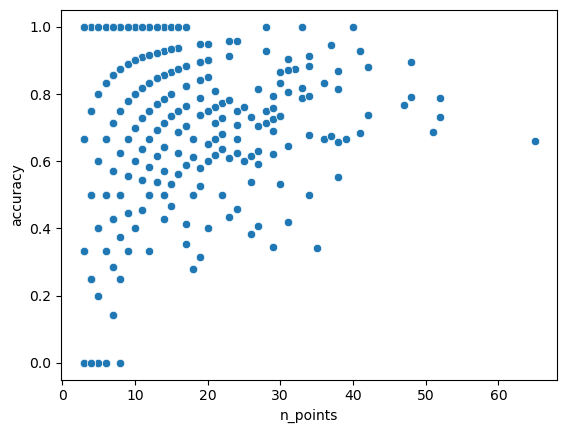

In [21]:
import pandas as pd
import geopandas as gpd
from pyproj import CRS
from tqdm import tqdm

# ---- reload MRoS hourly dataframe ----
mros_hr = pd.read_parquet(out_dir / "hourly_data/mros_hourly.parquet")

# ensure timestamp type matches what the interpolation script used
mros_hr["hour_utc"] = pd.to_datetime(mros_hr["hour_utc"], utc=True)

# -----------------------------------------------------------
# rebuild categorical phase and one-hot support columns
# -----------------------------------------------------------

def convert_legacy_proxy_to_phase(v):
    if pd.isna(v):
        return None
    if v == 0:
        return "snow"
    if v == 50:
        return "mix"
    if v == 100:
        return "rain"
    return None


# recover categorical phase
if "mros_phase" not in mros_hr.columns:

    if "mros_plp_proxy" in mros_hr.columns:
        mros_hr["mros_phase"] = mros_hr["mros_plp_proxy"].apply(convert_legacy_proxy_to_phase)

    elif "phase" in mros_hr.columns:
        mros_hr["mros_phase"] = mros_hr["phase"]

    else:
        raise ValueError("Could not find a phase column in MRoS parquet.")


# build one-hot support fields
mros_hr["mros_support_snow"] = (mros_hr["mros_phase"] == "snow").astype(float)
mros_hr["mros_support_mix"]  = (mros_hr["mros_phase"] == "mix").astype(float)
mros_hr["mros_support_rain"] = (mros_hr["mros_phase"] == "rain").astype(float)

# ---- recreate projection CRS used for interpolation ----
proj_crs = CRS.from_epsg(26911)

print("MRoS rows:", len(mros_hr))
print("Unique hours:", mros_hr["hour_utc"].nunique())
print("Mean obs/hour:", len(mros_hr) / mros_hr["hour_utc"].nunique())
print(mros_hr.groupby("hour_utc").size().describe())

from sklearn.metrics import accuracy_score, f1_score

cv_rows = []
cv_detail_rows = []

print("Running MRoS LOOCV...")
mros_hr = mros_hr.dropna(subset=["mros_phase"])
hours_with_mros = sorted(mros_hr["hour_utc"].unique())

for t in tqdm(hours_with_mros):

    mros_t = mros_hr[mros_hr["hour_utc"] == t].copy()

    if len(mros_t) < 3:
        continue

    cv_detail, cv_metrics = loocv_mros_hour(
        mros_t=mros_t,
        proj_crs=proj_crs,
        idw_power=CONFIG["idw_power"],
        k=CONFIG["k_nearest"],
        min_points=VAR_CONFIG["mros_support_snow"]["min_points"],
        z_scale=CONFIG["mros_vertical_scale"],
        eps=CONFIG["eps"],
    )

    cv_metrics["hour_utc"] = t

    cv_rows.append(cv_metrics)
    cv_detail_rows.append(cv_detail)


cv_hourly = pd.DataFrame(cv_rows)
print("Hours evaluated:", len(cv_hourly))

cv_hourly = cv_hourly.sort_values("hour_utc").reset_index(drop=True)
cv_hourly.to_csv("mros_loocv_hourly.csv", index=False)
cv_summary = pd.DataFrame([{
    "mean_accuracy": cv_hourly["accuracy"].mean(),
    "mean_macro_f1": cv_hourly["macro_f1"].mean(),
    "mean_n_points": cv_hourly["n_points"].mean(),
    "n_hours": len(cv_hourly),
}])

cv_summary.to_csv("mros_loocv_summary.csv", index=False)
print(cv_summary)

cv_hourly["n_points"].describe()
cv_hourly["accuracy"].describe()

cv_detail_all = pd.concat(cv_detail_rows).reset_index(drop=True)
cv_detail_all.to_csv("mros_loocv_station_level.csv", index=False)

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=cv_hourly,
    x="n_points",
    y="accuracy"
)

plt.show()

Plotting timestep: 2025-04-01 00:00:00
Stations: 57 | MRoS: 34


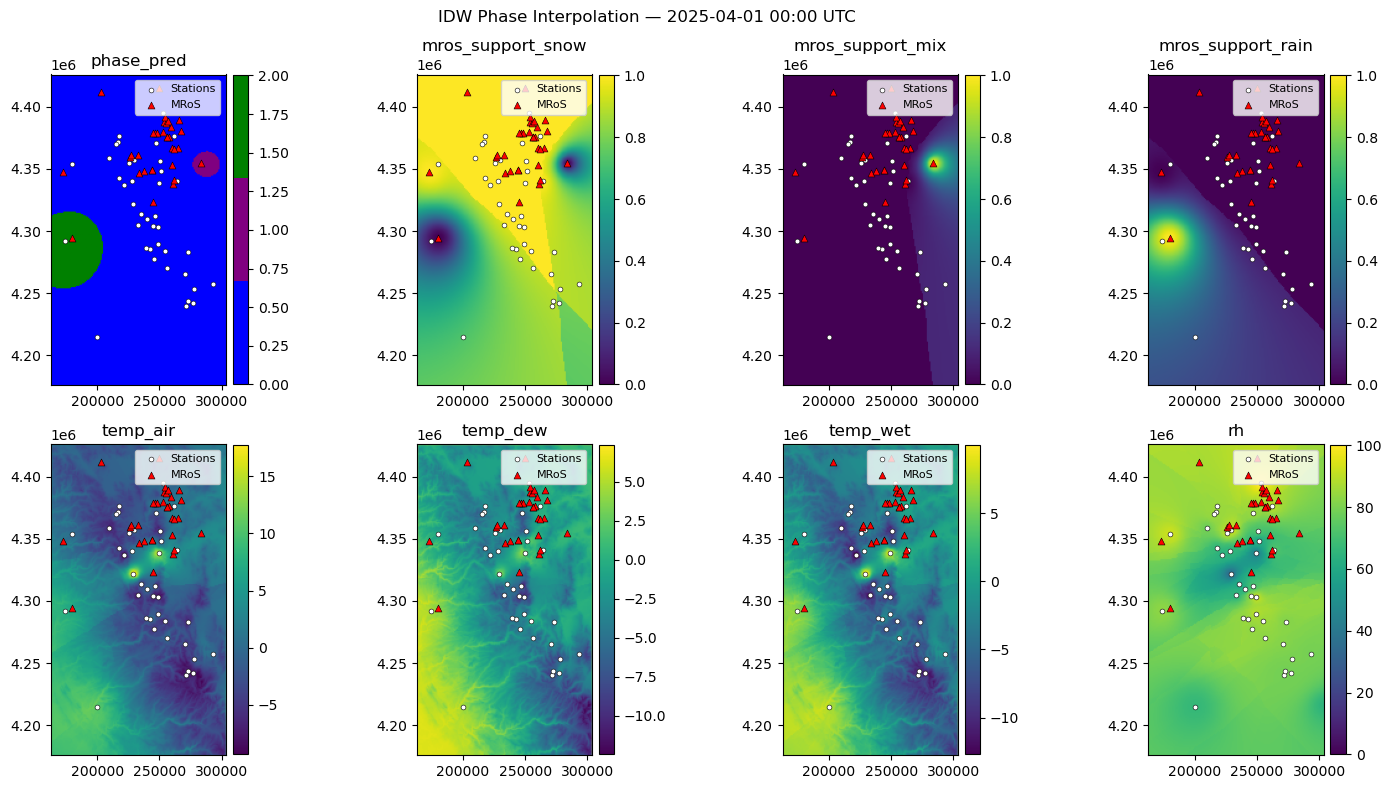

Quicklook complete.


In [29]:
# =============================================================================
# QUICKLOOK – IDW SUPPORT SURFACES (SINGLE DATE)
# =============================================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from matplotlib.colors import ListedColormap


# ------------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------------

IDW_PATH = Path(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\IDW\hourly_predictors_1km_IDW_onehot.nc")

STATION_PATH = Path(
"C:/Users/EmmaGolub/Desktop/MRoS_local/mros-precipitation-phase-product-prototype/outputs/hourly_pipeline/hourly_data/stations_hourly.parquet"
)

MROS_PATH = Path(
"C:/Users/EmmaGolub/Desktop/MRoS_local/mros-precipitation-phase-product-prototype/outputs/hourly_pipeline/hourly_data/mros_hourly.parquet"
)

TARGET_DATE = "2025-04-01"


# ------------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------------

ds = xr.open_dataset(IDW_PATH)

st_hr = pd.read_parquet(STATION_PATH)
mros_hr = pd.read_parquet(MROS_PATH)


# ------------------------------------------------------------------
# FIND TIMESTAMP
# ------------------------------------------------------------------

times = pd.to_datetime(ds.time.values)

mask = times.normalize() == pd.to_datetime(TARGET_DATE)

if not mask.any():
    raise ValueError(f"No timestep found for {TARGET_DATE}")

ti = np.where(mask)[0][0]
t_plot = times[ti]

print("Plotting timestep:", t_plot)


# ------------------------------------------------------------------
# GRID EXTENT
# ------------------------------------------------------------------

xmin, xmax = ds.x.min().item(), ds.x.max().item()
ymin, ymax = ds.y.min().item(), ds.y.max().item()

extent = [xmin, xmax, ymin, ymax]


# ------------------------------------------------------------------
# PROJECT OBSERVATIONS
# ------------------------------------------------------------------

crs_wkt = ds.spatial_ref.attrs["crs_wkt"]

tf = Transformer.from_crs("EPSG:4326", crs_wkt, always_xy=True)

st_time = st_hr["hour_utc"].dt.tz_convert(None)
mros_time = mros_hr["hour_utc"].dt.tz_convert(None)

st_t = st_hr[st_time.dt.floor("h") == t_plot]
mros_t = mros_hr[mros_time.dt.floor("h") == t_plot]

st_x, st_y = tf.transform(st_t.lon.values, st_t.lat.values)
mo_x, mo_y = tf.transform(mros_t.lon.values, mros_t.lat.values)

print(f"Stations: {len(st_x)} | MRoS: {len(mo_x)}")


# Clip stations to grid bounds
st_mask = (
    (st_x >= xmin) & (st_x <= xmax) &
    (st_y >= ymin) & (st_y <= ymax)
)

st_x = st_x[st_mask]
st_y = st_y[st_mask]


# Clip MRoS
mo_mask = (
    (mo_x >= xmin) & (mo_x <= xmax) &
    (mo_y >= ymin) & (mo_y <= ymax)
)

mo_x = mo_x[mo_mask]
mo_y = mo_y[mo_mask]

# ------------------------------------------------------------------
# BUILD PHASE MAP
# ------------------------------------------------------------------

snow = ds["mros_support_snow"].isel(time=ti).values
mix  = ds["mros_support_mix"].isel(time=ti).values
rain = ds["mros_support_rain"].isel(time=ti).values

phase_pred = np.argmax(np.stack([snow, mix, rain]), axis=0)

phase_cmap = ListedColormap(["blue", "purple", "green"])
# snow, mix, rain


# ------------------------------------------------------------------
# VARIABLES TO PLOT
# ------------------------------------------------------------------

vars_to_plot = [
    ("phase_pred", phase_pred),
    ("mros_support_snow", snow),
    ("mros_support_mix", mix),
    ("mros_support_rain", rain),
    ("temp_air", ds["temp_air"].isel(time=ti).values),
    ("temp_dew", ds["temp_dew"].isel(time=ti).values),
    ("temp_wet", ds["temp_wet"].isel(time=ti).values),
    ("rh", ds["rh"].isel(time=ti).values),
]


# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------

fig, axes = plt.subplots(2,4,figsize=(15,8))
axes = axes.flatten()

fig.suptitle(f"IDW Phase Interpolation — {t_plot:%Y-%m-%d %H:%M UTC}")

for i,(name,arr) in enumerate(vars_to_plot):

    ax = axes[i]

    if name == "phase_pred":
        im = ax.imshow(arr,origin="upper",extent=extent,cmap=phase_cmap,vmin=0,vmax=2)

    elif name.startswith("mros_support"):
        im = ax.imshow(arr,origin="upper",extent=extent,vmin=0,vmax=1)

    elif name == "rh":
        im = ax.imshow(arr,origin="upper",extent=extent,vmin=0,vmax=100)

    else:
        im = ax.imshow(arr,origin="upper",extent=extent)

    ax.set_title(name)

    if len(st_x):
        ax.scatter(st_x,st_y,s=12,c="white",edgecolor="black",linewidth=0.4,label="Stations")

    if len(mo_x):
        ax.scatter(mo_x,mo_y,s=25,c="red",marker="^",edgecolor="black",linewidth=0.4,label="MRoS")

    ax.legend(loc="upper right",fontsize=8)

    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.02)


plt.tight_layout()
plt.show()

print("Quicklook complete.")